In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
df = pd.read_csv('dataset_balanceado_pronto.csv')
input_dim = 6
n_features = 6
output_dim = 2
num_epochs = 10000
learning_rate = 0.01
test_size = 0.3
random_state = 42

In [5]:
df.head()

,massFlow_1,massFlow_2,massFlow_3,massFlow_4,massFlow_5,massFlow_6,anomaly
0,0.261122,0.261525,0.257016,0.263706,0.264042,0.258191,0
1,0.248733,0.251273,0.252975,0.249206,0.258848,0.253853,0
2,0.254494,0.252283,0.254897,0.259973,0.255765,0.256653,0
3,0.251353,0.254784,0.256152,0.252397,0.255100,0.257605,0
4,0.251210,0.246467,0.242903,0.247801,0.242971,0.249442,0


In [6]:

feature_cols = [col for col in df.columns if col != "anomaly"]
X = df[feature_cols].values
y = df['anomaly'].values

In [7]:
scaler = StandardScaler()

In [8]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= test_size, random_state= random_state)

X_train_reshaped = X_train.reshape(-1, n_features) 
X_test_reshaped = X_test.reshape(-1, n_features)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)


In [9]:
class NeuralNetworkClassificationModel(nn.Module):
    def __init__(self,input_dim,output_dim):
        super(NeuralNetworkClassificationModel,self).__init__()
        self.input_layer    = nn.Linear(input_dim,128)
        self.hidden_layer1  = nn.Linear(128,64)
        self.output_layer   = nn.Linear(64,output_dim)
        self.relu = nn.ReLU()
    
    
    def forward(self,x):
        out =  self.relu(self.input_layer(x))
        out =  self.relu(self.hidden_layer1(out))
        out =  self.output_layer(out)
        return out

In [10]:
# input_dim = 4 because we have 4 inputs namely sepal_length,sepal_width,petal_length,petal_width
# output_dim = 3 because we have namely 3 categories setosa,versicolor and virginica
input_dim  = input_dim
output_dim = output_dim
model = NeuralNetworkClassificationModel(input_dim,output_dim)

In [11]:
# creating our optimizer and loss function object
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

In [12]:
def train_network(model,optimizer,criterion,X_train,y_train,X_test,y_test,num_epochs,train_losses,test_losses):
    for epoch in range(num_epochs):
        #clear out the gradients from the last step loss.backward()
        optimizer.zero_grad()
        
        #forward feed
        output_train = model(X_train)

        #calculate the loss
        loss_train = criterion(output_train, y_train)
        
        #backward propagation: calculate gradients
        loss_train.backward()

        #update the weights
        optimizer.step()
        
        output_test = model(X_test)
        loss_test = criterion(output_test,y_test)

        train_losses[epoch] = loss_train.item()
        test_losses[epoch] = loss_test.item()

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss_train.item():.4f}, Test Loss: {loss_test.item():.4f}")

In [13]:

train_losses = np.zeros(num_epochs)
test_losses  = np.zeros(num_epochs)
print(X_train.shape)  # Deve ser (n_amostras, 1)
print(X_train[:10])  # Exibe as primeiras 10 amostras

torch.Size([137, 6])
tensor([[0.2527, 0.2538, 0.2540, 0.2514, 0.2548, 0.2562],
        [0.2415, 0.2447, 0.2434, 0.2476, 0.2474, 0.2385],
        [0.2529, 0.2566, 0.2464, 0.2527, 0.2538, 0.2540],
        [0.2546, 0.2477, 0.2509, 0.2521, 0.2580, 0.2574],
        [0.2576, 0.2562, 0.2606, 0.2543, 0.2590, 0.2538],
        [0.2545, 0.2522, 0.2526, 0.2602, 0.2524, 0.2456],
        [0.2605, 0.2617, 0.2638, 0.2599, 0.2549, 0.2541],
        [0.2472, 0.2474, 0.2538, 0.2475, 0.2457, 0.2455],
        [0.2452, 0.2382, 0.2424, 0.2395, 0.2445, 0.2418],
        [0.2536, 0.2542, 0.2603, 0.2605, 0.2622, 0.2576]])


In [14]:
train_losses = np.zeros(num_epochs)
test_losses  = np.zeros(num_epochs)

print(X_train.shape)  # Deve ser (n_amostras, 1)

torch.Size([137, 6])


In [15]:
train_network(model,optimizer,criterion,X_train,y_train,X_test,y_test,num_epochs,train_losses,test_losses)

Epoch 50/10000, Train Loss: 0.6929, Test Loss: 0.6928
Epoch 100/10000, Train Loss: 0.6718, Test Loss: 0.6354
Epoch 150/10000, Train Loss: 0.5904, Test Loss: 0.4844
Epoch 200/10000, Train Loss: 0.5704, Test Loss: 0.4483
Epoch 250/10000, Train Loss: 0.5649, Test Loss: 0.4438
Epoch 300/10000, Train Loss: 0.5568, Test Loss: 0.4262
Epoch 350/10000, Train Loss: 0.5514, Test Loss: 0.4218
Epoch 400/10000, Train Loss: 0.5533, Test Loss: 0.4167
Epoch 450/10000, Train Loss: 0.5407, Test Loss: 0.4110
Epoch 500/10000, Train Loss: 0.5385, Test Loss: 0.4138
Epoch 550/10000, Train Loss: 0.5347, Test Loss: 0.4127
Epoch 600/10000, Train Loss: 0.5276, Test Loss: 0.4041
Epoch 650/10000, Train Loss: 0.5148, Test Loss: 0.4007
Epoch 700/10000, Train Loss: 0.5068, Test Loss: 0.3973
Epoch 750/10000, Train Loss: 0.5064, Test Loss: 0.4009
Epoch 800/10000, Train Loss: 0.4961, Test Loss: 0.3889
Epoch 850/10000, Train Loss: 0.4881, Test Loss: 0.3885
Epoch 900/10000, Train Loss: 0.4790, Test Loss: 0.3850
Epoch 950/1

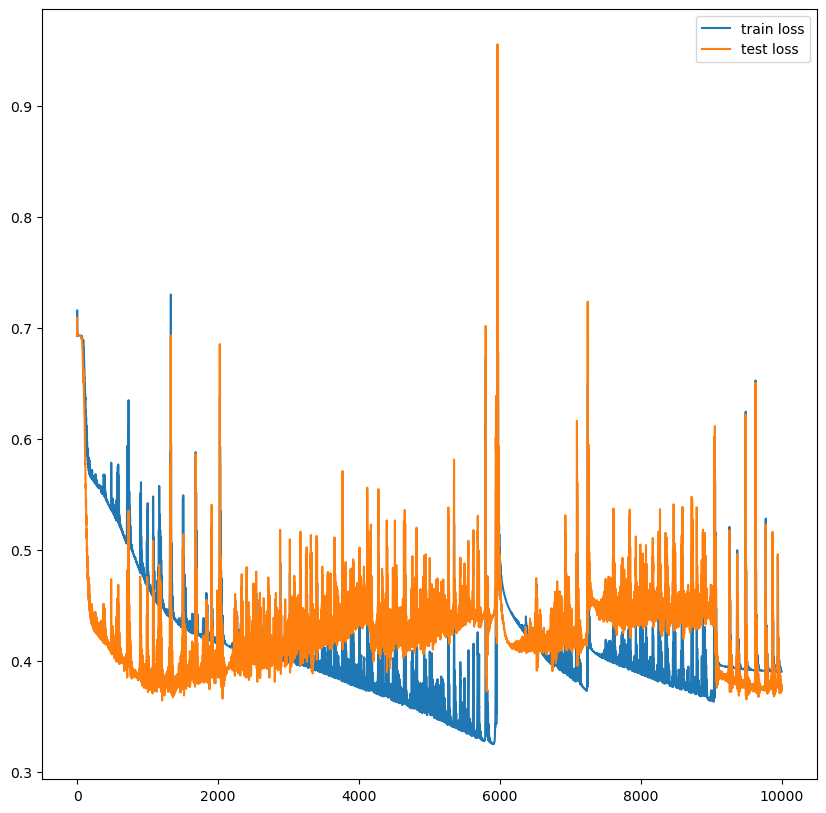

In [16]:
plt.figure(figsize=(10,10))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

In [17]:
predictions_train = []
predictions_test =  []
with torch.no_grad():
    predictions_train = model(X_train)
    predictions_test = model(X_test)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def get_accuracy_multiclass(pred_arr, original_arr, label="Dataset"):
    if len(pred_arr) != len(original_arr):
        return False

    pred_arr = pred_arr.numpy()
    original_arr = original_arr.numpy()

    final_pred = []

    for i in range(len(pred_arr)):
        final_pred.append(np.argmax(pred_arr[i]))

    final_pred = np.array(final_pred)

    count = 0
    for i in range(len(original_arr)):
        if final_pred[i] == original_arr[i]:
            count += 1

    acc = count / len(final_pred)

    print(f"\n{'='*10} {label.upper()} METRICS {'='*10}")
    print("\n> Confusion Matrix:")
    print(confusion_matrix(original_arr, final_pred))
    
    print("\n> Classification Report:")
    print(classification_report(original_arr, final_pred, digits=4))

    print(f"> Accuracy: {acc:.4f}")

    return acc


In [19]:
train_acc = get_accuracy_multiclass(predictions_train, y_train, label="Training Set")
test_acc  = get_accuracy_multiclass(predictions_test, y_test, label="Test Set")



========== TRAINING SET METRICS ==========

> Confusion Matrix:
[[60  8]
 [17 52]]

> Classification Report:
              precision    recall  f1-score   support

           0     0.7792    0.8824    0.8276        68
           1     0.8667    0.7536    0.8062        69

    accuracy                         0.8175       137
   macro avg     0.8229    0.8180    0.8169       137
weighted avg     0.8233    0.8175    0.8168       137

> Accuracy: 0.8175

========== TEST SET METRICS ==========

> Confusion Matrix:
[[26  4]
 [ 6 23]]

> Classification Report:
              precision    recall  f1-score   support

           0     0.8125    0.8667    0.8387        30
           1     0.8519    0.7931    0.8214        29

    accuracy                         0.8305        59
   macro avg     0.8322    0.8299    0.8301        59
weighted avg     0.8318    0.8305    0.8302        59

> Accuracy: 0.8305


Training Accuracy: 81.752
Test Accuracy: 83.051


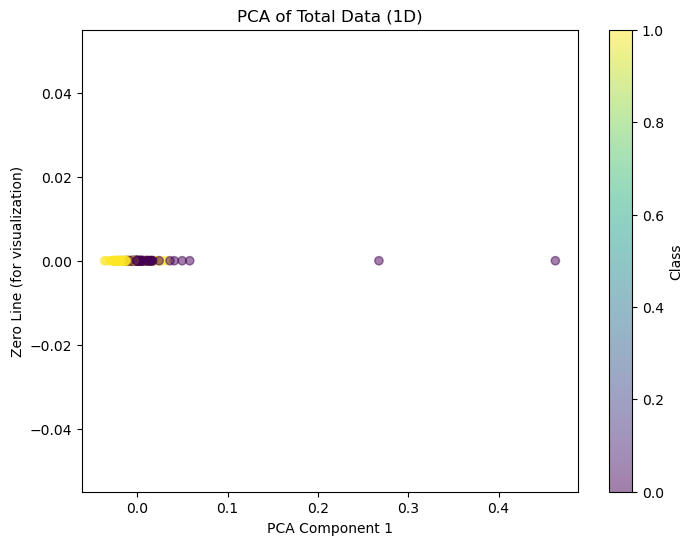

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aqui, você já tem o cálculo das acurácias
print(f"Training Accuracy: {round(train_acc*100,3)}")
print(f"Test Accuracy: {round(test_acc*100,3)}")

# Aplicando PCA para reduzir as dimensões para 1 (pois temos 1 feature)
pca = PCA(n_components=1)

# Reduzindo as dimensões dos dados totais (treinamento + teste)
X_total = torch.cat((X_train, X_test), dim=0)  # Concatenando os dados de treino e teste
X_total_pca = pca.fit_transform(X_total)  # Aplicando o PCA no conjunto total

# Plotando os resultados de PCA
plt.figure(figsize=(8, 6))

# Plotando os dados totais
plt.scatter(X_total_pca[:, 0], np.zeros_like(X_total_pca[:, 0]), c=torch.cat((y_train, y_test)), cmap='viridis', alpha=0.5)

# Adicionando títulos e legendas
plt.title('PCA of Total Data (1D)')
plt.xlabel('PCA Component 1')
plt.ylabel('Zero Line (for visualization)')
plt.colorbar(label='Class')

plt.show()

# PCA(n_components=1): Reduz os dados para apenas 1 componente principal.

# torch.cat((X_train, X_test), dim=0): Combina os dados de treino e teste em um único array/tensor (X_total).

# fit_transform(X_total): Calcula o PCA e transforma os dados para o novo espaço 1D.

# Eixo X: Valores da componente principal 1 (X_total_pca[:, 0]).

# Eixo Y: Uma linha de zeros (np.zeros_like), apenas para visualização (já que os dados são 1D).

# Cores: Definidas pelas classes (y_train e y_test concatenadas), usando o colormap viridis.

# Distribuição 1D: Mostra como as amostras se distribuem ao longo da única componente principal.

# Separação de Classes:

# Se as classes (cores) estiverem bem separadas ao longo do eixo X, a componente 1 é discriminativa.

# Se estiverem misturadas, a feature original não separa bem as classes.

# PCA(n_components=1) cria uma nova componente que é uma combinação linear de time e massFlow.

# A fórmula seria algo como:
# PC1 = a * time + b * massFlow
# (onde a e b são os "loadings" calculados pelo PCA)



In [162]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

# # 1. Preparar os dados
# X = df1[['time', 'massFlow']].values  # Features (time e massFlow)
# y = df1['anomaly'].values             # Rótulos (anomaly)

# # 2. Aplicar PCA para reduzir para 2 componentes (para visualização)
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# # 3. Criar um mapa de cores para as classes (assumindo que 'n_amac' é a classe normal)
# classes = np.unique(y)
# colors = {'n_amac': 'blue', 'n_sab': 'red', 'amac': 'green'}  # Defina cores para cada classe

# # 4. Plotar os resultados
# plt.figure(figsize=(10, 6))

# # Plotar cada classe separadamente para legenda clara
# for cls in classes:
#     mask = (y == cls)
#     plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
#                c=colors.get(cls, 'gray'), 
#                label=cls, 
#                alpha=0.7)

# # Adicionar títulos e legendas
# plt.title('PCA of Time vs. MassFlow (2D)')
# plt.xlabel('Principal Component 1 (PC1)')
# plt.ylabel('Principal Component 2 (PC2)')
# plt.legend()
# plt.grid(True)

# # Mostrar a variância explicada por cada componente
# explained_var = pca.explained_variance_ratio_
# print(f"Variância explicada: PC1 = {explained_var[0]:.2%}, PC2 = {explained_var[1]:.2%}")

# plt.show()


# # X: Extrai as colunas 'time' e 'massFlow' do DataFrame df1 e converte para um array NumPy

# # y: Extrai a coluna 'anomaly' (que contém as classes/labels) como um array NumPy

# # Eixo X: Primeiro componente principal (PC1)

# # Eixo Y: Segundo componente principal (PC2)

# # Cores: Classes diferentes (n_amac, n_sab, amac)

# # Pontos: Cada ponto representa uma observação no novo espaço 2D